In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from pathlib import Path
from collections import defaultdict

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
OUT_DIR  = Path("kg_output")
 
nodes_df = pd.read_csv(OUT_DIR / "kg_nodes.csv")
edges_df = pd.read_csv(OUT_DIR / "kg_edges.csv")
 
print(f"Nodes: {len(nodes_df):,}  |  Edges: {len(edges_df):,}")

Nodes: 3,460  |  Edges: 23,051


In [3]:

# ═══════════════════════════════════════════════════════════
# Cell 3 — A: 图结构指标
# ═══════════════════════════════════════════════════════════
G = nx.DiGraph()
for _, row in nodes_df.iterrows():
    G.add_node(row["id"], label=row["label"])
for _, row in edges_df.iterrows():
    G.add_edge(row["src"], row["dst"], rel=row["rel"])
 
G_und = G.to_undirected()
 
# 基本指标
n_nodes   = G.number_of_nodes()
n_edges   = G.number_of_edges()
density   = nx.density(G)
avg_deg   = sum(d for _, d in G.degree()) / n_nodes
avg_in    = sum(d for _, d in G.in_degree())  / n_nodes
avg_out   = sum(d for _, d in G.out_degree()) / n_nodes
 
# 连通性
n_wcc     = nx.number_weakly_connected_components(G)
largest   = max(nx.weakly_connected_components(G), key=len)
lcc_ratio = len(largest) / n_nodes
 
# 度分布统计
degrees   = [d for _, d in G.degree()]
max_deg   = max(degrees)
median_deg= float(np.median(degrees))
 
struct_metrics = {
    "Total nodes":               n_nodes,
    "Total edges":               n_edges,
    "Graph density":             round(density, 6),
    "Avg degree":                round(avg_deg, 2),
    "Avg in-degree":             round(avg_in,  2),
    "Avg out-degree":            round(avg_out, 2),
    "Max degree":                max_deg,
    "Median degree":             median_deg,
    "Weakly connected components": n_wcc,
    "Largest CC ratio":          round(lcc_ratio, 4),
}
 
print("\n=== A. Graph Structure Metrics ===")
for k, v in struct_metrics.items():
    print(f"  {k:<35}: {v}")
 
# 节点 & 边类型分布
print("\nNode label distribution:")
print(nodes_df["label"].value_counts().to_string())
print("\nEdge type distribution:")
print(edges_df["rel"].value_counts().to_string())
 


=== A. Graph Structure Metrics ===
  Total nodes                        : 3460
  Total edges                        : 15472
  Graph density                      : 0.001293
  Avg degree                         : 8.94
  Avg in-degree                      : 4.47
  Avg out-degree                     : 4.47
  Max degree                         : 1116
  Median degree                      : 5.0
  Weakly connected components        : 1
  Largest CC ratio                   : 1.0

Node label distribution:
label
FundusImage     689
OpticDisc       689
NeuralRim       689
Pathology       689
Diagnosis       689
ClinicalRule     11
RiskLevel         4

Edge type distribution:
rel
GOVERNED_BY           15158
SUPPORTS_RULE          3004
SUPPORTS_DIAGNOSIS     1444
HAS_OPTIC_DISC          689
HAS_RIM                 689
HAS_PATHOLOGY           689
HAS_DIAGNOSIS           689
HAS_RISK                689



=== B. Biomarker Discriminability Metrics ===
         Biomarker  Precision  Recall    F1   AUC
      rim_thinning        1.0   1.000 1.000 1.000
     ISNT violated        1.0   1.000 1.000 1.000
           CDR≥0.7        1.0   0.998 0.999 0.999
        bayoneting        1.0   0.728 0.843 0.864
          notching        1.0   0.728 0.843 0.864
        rim_pallor        1.0   0.724 0.840 0.862
  laminar_dot_sign        1.0   0.550 0.710 0.775
isnt_rule_followed        0.0   0.000 0.000 0.000


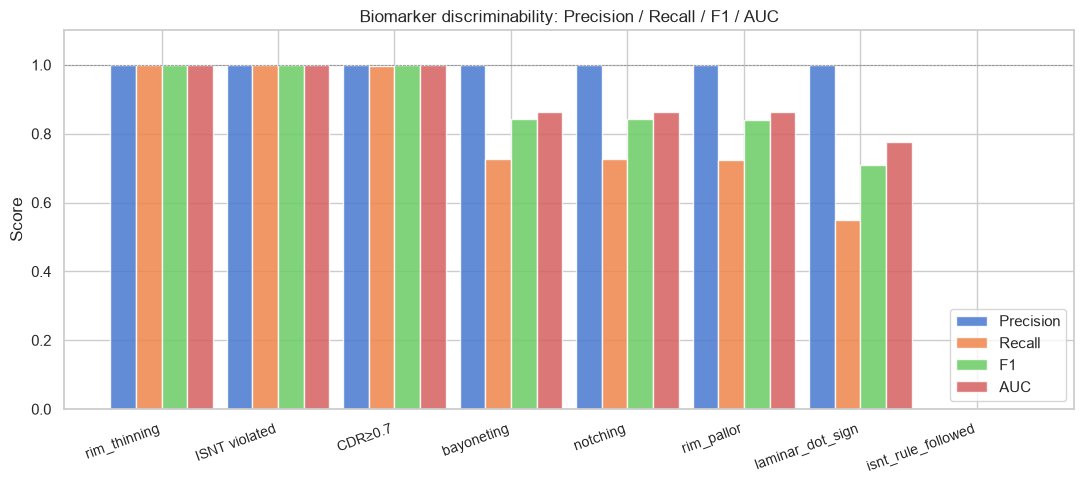

In [4]:
# ═══════════════════════════════════════════════════════════
# Cell 4 — B: Biomarker 区分度指标
# ═══════════════════════════════════════════════════════════
 
# 构建 master table
img_ann  = nodes_df[nodes_df.label=="FundusImage"].set_index("id")["annotation"]
has_diag = edges_df[edges_df.rel=="HAS_DIAGNOSIS"][["src","dst"]].rename(columns={"src":"img_id","dst":"diag_id"})
has_od   = edges_df[edges_df.rel=="HAS_OPTIC_DISC"][["src","dst"]].rename(columns={"src":"img_id","dst":"od_id"})
has_rim  = edges_df[edges_df.rel=="HAS_RIM"][["src","dst"]].rename(columns={"src":"img_id","dst":"rim_id"})
has_path = edges_df[edges_df.rel=="HAS_PATHOLOGY"][["src","dst"]].rename(columns={"src":"img_id","dst":"path_id"})
 
master = (has_diag.merge(has_od, on="img_id")
                  .merge(has_rim, on="img_id")
                  .merge(has_path, on="img_id"))
master["annotation"] = master["img_id"].map(img_ann)
 
od_cols   = nodes_df[nodes_df.label=="OpticDisc"][["id","cup_to_disc_ratio"]].rename(columns={"id":"od_id"})
rim_cols  = nodes_df[nodes_df.label=="NeuralRim"][["id","isnt_rule_followed","rim_pallor","rim_thinning"]].rename(columns={"id":"rim_id"})
path_cols = nodes_df[nodes_df.label=="Pathology"][["id","bayoneting","notching","laminar_dot_sign"]].rename(columns={"id":"path_id"})
 
master = (master.merge(od_cols,   on="od_id")
                .merge(rim_cols,  on="rim_id")
                .merge(path_cols, on="path_id"))
 
# bool 转换
bool_cols = ["isnt_rule_followed","rim_pallor","rim_thinning",
             "bayoneting","notching","laminar_dot_sign"]
for c in bool_cols:
    master[c] = master[c].map({True:True,False:False,"True":True,"False":False})
 
master["cup_to_disc_ratio"] = pd.to_numeric(master["cup_to_disc_ratio"], errors="coerce")
master["y_true"] = (master["annotation"] == "glaucoma").astype(int)
 
# CDR threshold → binary
master["cdr_pred"] = (master["cup_to_disc_ratio"] >= 0.7).astype(int)
 
# ISNT violation → binary
master["isnt_pred"] = (~master["isnt_rule_followed"].fillna(True)).astype(int)
 
bm_results = []
for col in bool_cols + ["cdr_pred", "isnt_pred"]:
    col_data = master[col]
    if col in ("cdr_pred", "isnt_pred"):
        y_pred = col_data.fillna(0).astype(int)
        name   = "CDR≥0.7" if col == "cdr_pred" else "ISNT violated"
    else:
        y_pred = col_data.fillna(False).astype(int)
        name   = col
 
    y_true = master["y_true"]
    valid  = y_pred.notna() & y_true.notna()
    yt, yp = y_true[valid], y_pred[valid]
 
    p  = precision_score(yt, yp, zero_division=0)
    r  = recall_score(yt, yp, zero_division=0)
    f1 = f1_score(yt, yp, zero_division=0)
    try:
        auc = roc_auc_score(yt, yp)
    except Exception:
        auc = float("nan")
 
    bm_results.append({"Biomarker": name,
                        "Precision": round(p, 3),
                        "Recall":    round(r, 3),
                        "F1":        round(f1, 3),
                        "AUC":       round(auc, 3)})
 
bm_df = pd.DataFrame(bm_results).sort_values("F1", ascending=False)
print("\n=== B. Biomarker Discriminability Metrics ===")
print(bm_df.to_string(index=False))
 
# 可视化
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(bm_df))
w = 0.22
ax.bar(x - w*1.5, bm_df["Precision"], w, label="Precision", alpha=0.85)
ax.bar(x - w*0.5, bm_df["Recall"],    w, label="Recall",    alpha=0.85)
ax.bar(x + w*0.5, bm_df["F1"],        w, label="F1",        alpha=0.85)
ax.bar(x + w*1.5, bm_df["AUC"],       w, label="AUC",       alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(bm_df["Biomarker"], rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Biomarker discriminability: Precision / Recall / F1 / AUC")
ax.legend()
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.savefig(OUT_DIR / "eval_B_biomarker.png", dpi=150)
plt.show()
 


=== C. Clinical Rule Coverage ===
                               name strength      evidence  hit_count  coverage_%
                ISNT rule violation   strong      glaucoma        427        62.0
                  Rim thinning rule   strong      glaucoma        427        62.0
            CDR high risk threshold   strong      glaucoma        426        61.8
                    Bayoneting sign moderate      glaucoma        311        45.1
                      Notching sign moderate      glaucoma        311        45.1
                    Rim pallor rule moderate      glaucoma        309        44.8
Bayoneting + notching co-occurrence   strong      glaucoma        295        42.8
                   CDR normal range   strong        normal        262        38.0
                   Laminar dot sign     weak      glaucoma        235        34.1
        CDR moderate risk threshold moderate moderate_risk          1         0.1

Rules per diagnosis — mean: 4.36  median: 3  max: 8
  Covered 

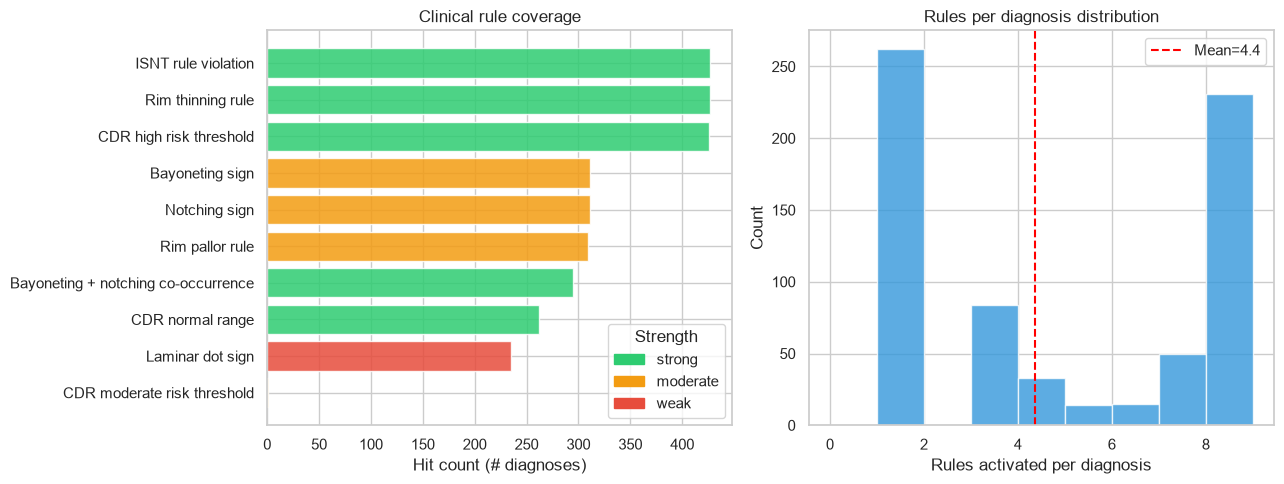

In [5]:
# ═══════════════════════════════════════════════════════════
# Cell 5 — C: 临床规则覆盖率
# ═══════════════════════════════════════════════════════════
rules_df  = nodes_df[nodes_df.label == "ClinicalRule"].copy()
sup_edges = edges_df[edges_df.rel == "SUPPORTS_RULE"]
diag_nodes= nodes_df[nodes_df.label == "Diagnosis"]
 
# 每条规则命中的 Diagnosis 数
rule_hits = sup_edges.groupby("dst")["src"].count().reset_index()
rule_hits.columns = ["rule_id", "hit_count"]
rule_hits = rule_hits.merge(
    rules_df[["id","name","strength","evidence"]].rename(columns={"id":"rule_id"}),
    on="rule_id", how="left"
)
rule_hits["coverage_%"] = (rule_hits["hit_count"] / len(diag_nodes) * 100).round(1)
rule_hits = rule_hits.sort_values("hit_count", ascending=False)
 
print("\n=== C. Clinical Rule Coverage ===")
print(rule_hits[["name","strength","evidence","hit_count","coverage_%"]].to_string(index=False))
 
# 每个病例激活的规则数分布
rules_per_diag = sup_edges.groupby("src")["dst"].count()
print(f"\nRules per diagnosis — mean: {rules_per_diag.mean():.2f}  "
      f"median: {rules_per_diag.median():.0f}  "
      f"max: {rules_per_diag.max()}")
 
# 规则组合覆盖率（至少命中 k 条规则的病例比例）
total_diag = len(diag_nodes)
for k in [1, 2, 3, 4, 5]:
    covered = (rules_per_diag >= k).sum()
    print(f"  Covered by ≥{k} rules: {covered}/{total_diag} ({covered/total_diag*100:.1f}%)")
 
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# 规则命中数柱状图
colors = {"strong": "#2ecc71", "moderate": "#f39c12", "weak": "#e74c3c"}
bar_colors = [colors.get(str(s), "#888") for s in rule_hits["strength"]]
axes[0].barh(rule_hits["name"], rule_hits["hit_count"],
             color=bar_colors, alpha=0.85)
axes[0].set_xlabel("Hit count (# diagnoses)")
axes[0].set_title("Clinical rule coverage")
axes[0].invert_yaxis()
# legend
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=k) for k, c in colors.items()]
axes[0].legend(handles=legend_els, title="Strength", loc="lower right")
 
# 每病例激活规则数分布
axes[1].hist(rules_per_diag, bins=range(0, int(rules_per_diag.max())+2),
             color="#3498db", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("Rules activated per diagnosis")
axes[1].set_ylabel("Count")
axes[1].set_title("Rules per diagnosis distribution")
axes[1].axvline(rules_per_diag.mean(), color="red", linestyle="--",
                linewidth=1.5, label=f"Mean={rules_per_diag.mean():.1f}")
axes[1].legend()
 
plt.tight_layout()
plt.savefig(OUT_DIR / "eval_C_rule_coverage.png", dpi=150)
plt.show()
 

=== D. Reasoning Chain Quality ===
Avg strong   per diagnosis : 2.67
Avg moderate per diagnosis : 1.35
Avg weak     per diagnosis : 0.34
Avg chain score            : 11.04
Max chain score            : 19

Chain score by annotation:
            count   mean   std  min   25%   50%   75%   max
annotation                                                 
glaucoma    427.0  15.98  4.16  8.0  11.0  19.0  19.0  19.0
normal      262.0   3.00  0.00  3.0   3.0   3.0   3.0   3.0


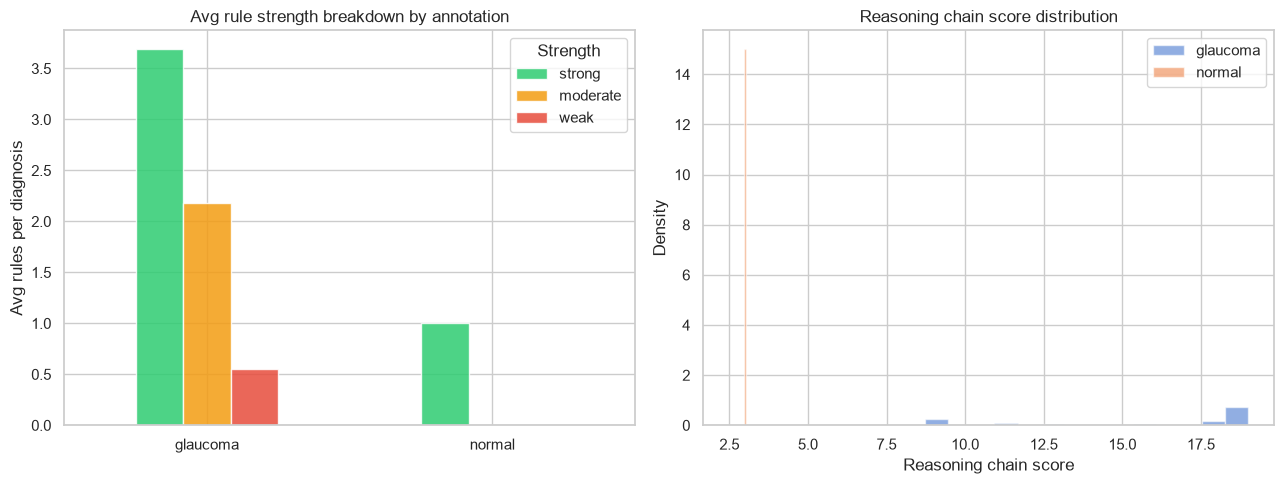

Saved: kg_output/eval_D_reasoning_chain.png


In [6]:


OUT_DIR = Path("kg_output")

sup_edges = edges_df[edges_df.rel == "SUPPORTS_RULE"].copy()
rules_df  = nodes_df[nodes_df.label == "ClinicalRule"].copy()

# 纯 Python 字典，完全不走 pandas 列索引
strength_map = {}
for _, row in rules_df.iterrows():
    strength_map[str(row["id"])] = str(row["strength"]).strip().lower()

diag_counts = defaultdict(lambda: {"strong": 0, "moderate": 0, "weak": 0})
for _, row in sup_edges.iterrows():
    d = str(row["src"])
    r = str(row["dst"])
    s = strength_map.get(r, "weak")
    diag_counts[d][s] += 1

records = []
for diag_id, c in diag_counts.items():
    records.append({
        "diag_id":     diag_id,
        "strong":      c["strong"],
        "moderate":    c["moderate"],
        "weak":        c["weak"],
        "chain_score": c["strong"] * 3 + c["moderate"] * 2 + c["weak"] * 1
    })
sd = pd.DataFrame(records)

# 连接 annotation
diag_ann = (
    edges_df[edges_df.rel == "HAS_DIAGNOSIS"][["src", "dst"]]
    .rename(columns={"src": "img_id", "dst": "diag_id"})
    .merge(
        nodes_df[nodes_df.label == "FundusImage"][["id", "annotation"]]
        .rename(columns={"id": "img_id"}),
        on="img_id"
    )
)
ann_map = dict(zip(diag_ann["diag_id"].astype(str), diag_ann["annotation"]))
sd["annotation"] = sd["diag_id"].map(ann_map)

print("=== D. Reasoning Chain Quality ===")
print(f"Avg strong   per diagnosis : {sd['strong'].mean():.2f}")
print(f"Avg moderate per diagnosis : {sd['moderate'].mean():.2f}")
print(f"Avg weak     per diagnosis : {sd['weak'].mean():.2f}")
print(f"Avg chain score            : {sd['chain_score'].mean():.2f}")
print(f"Max chain score            : {sd['chain_score'].max()}")
print("\nChain score by annotation:")
print(sd.groupby("annotation")["chain_score"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ann_strength = sd.groupby("annotation")[["strong", "moderate", "weak"]].mean()
ann_strength.plot(kind="bar", ax=axes[0],
                  color=["#2ecc71", "#f39c12", "#e74c3c"],
                  alpha=0.85, edgecolor="white")
axes[0].set_title("Avg rule strength breakdown by annotation")
axes[0].set_xlabel("")
axes[0].set_ylabel("Avg rules per diagnosis")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Strength")

for ann, grp in sd.groupby("annotation"):
    axes[1].hist(grp["chain_score"], bins=15, alpha=0.6, label=ann, density=True)
axes[1].set_xlabel("Reasoning chain score")
axes[1].set_ylabel("Density")
axes[1].set_title("Reasoning chain score distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "eval_D_reasoning_chain.png", dpi=150)
plt.show()
print("Saved: kg_output/eval_D_reasoning_chain.png")

In [8]:

# ═══════════════════════════════════════════════════════════
# Cell 7 — 汇总表（论文 Table 用）
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SUMMARY TABLE — Glaucoma Knowledge Graph Evaluation")
print("="*60)
 
print("\n[A] Graph Structure")
print(f"  Nodes                        : {n_nodes:,}")
print(f"  Edges                        : {n_edges:,}")
print(f"  Density                      : {density:.6f}")
print(f"  Avg degree                   : {avg_deg:.2f}")
print(f"  Largest CC ratio             : {lcc_ratio:.4f}")
 
print("\n[B] Biomarker Discriminability (top-3 by F1)")
top3 = bm_df.head(3)
for _, r in top3.iterrows():
    print(f"  {r['Biomarker']:<22}: P={r['Precision']:.3f}  R={r['Recall']:.3f}  F1={r['F1']:.3f}  AUC={r['AUC']:.3f}")
 
print("\n[C] Clinical Rule Coverage")
print(f"  Total rules                  : {len(rules_df)}")
print(f"  Avg rules per diagnosis      : {rules_per_diag.mean():.2f}")
print(f"  Diagnoses covered (≥1 rule)  : {(rules_per_diag>=1).sum()}/{total_diag} ({(rules_per_diag>=1).sum()/total_diag*100:.1f}%)")
print(f"  Diagnoses covered (≥3 rules) : {(rules_per_diag>=3).sum()}/{total_diag} ({(rules_per_diag>=3).sum()/total_diag*100:.1f}%)")
 
print("\n[D] Reasoning Chain Quality")
print(f"  Avg chain score              : {sd['chain_score'].mean():.2f}")
print(f"  Avg strong rules (glaucoma)  : {sd[sd.annotation=='glaucoma']['strong'].mean():.2f}")
print(f"  Avg strong rules (normal)    : {sd[sd.annotation=='normal']['strong'].mean():.2f}")
 
print(f"\nFigures saved to kg_output/")
print("  eval_B_biomarker.png")
print("  eval_C_rule_coverage.png")
print("  eval_D_reasoning_chain.png")
 


SUMMARY TABLE — Glaucoma Knowledge Graph Evaluation

[A] Graph Structure
  Nodes                        : 3,460
  Edges                        : 15,472
  Density                      : 0.001293
  Avg degree                   : 8.94
  Largest CC ratio             : 1.0000

[B] Biomarker Discriminability (top-3 by F1)
  rim_thinning          : P=1.000  R=1.000  F1=1.000  AUC=1.000
  ISNT violated         : P=1.000  R=1.000  F1=1.000  AUC=1.000
  CDR≥0.7               : P=1.000  R=0.998  F1=0.999  AUC=0.999

[C] Clinical Rule Coverage
  Total rules                  : 11
  Avg rules per diagnosis      : 4.36
  Diagnoses covered (≥1 rule)  : 689/689 (100.0%)
  Diagnoses covered (≥3 rules) : 427/689 (62.0%)

[D] Reasoning Chain Quality
  Avg chain score              : 11.04
  Avg strong rules (glaucoma)  : 3.69
  Avg strong rules (normal)    : 1.00

Figures saved to kg_output/
  eval_B_biomarker.png
  eval_C_rule_coverage.png
  eval_D_reasoning_chain.png
